695. Max Area of Island
Medium
Topics
premium lock icon
Companies
You are given an m x n binary matrix grid. An island is a group of 1's (representing land) connected 4-directionally (horizontal or vertical.) You may assume all four edges of the grid are surrounded by water.

The area of an island is the number of cells with a value 1 in the island.

Return the maximum area of an island in grid. If there is no island, return 0.

Example 1:

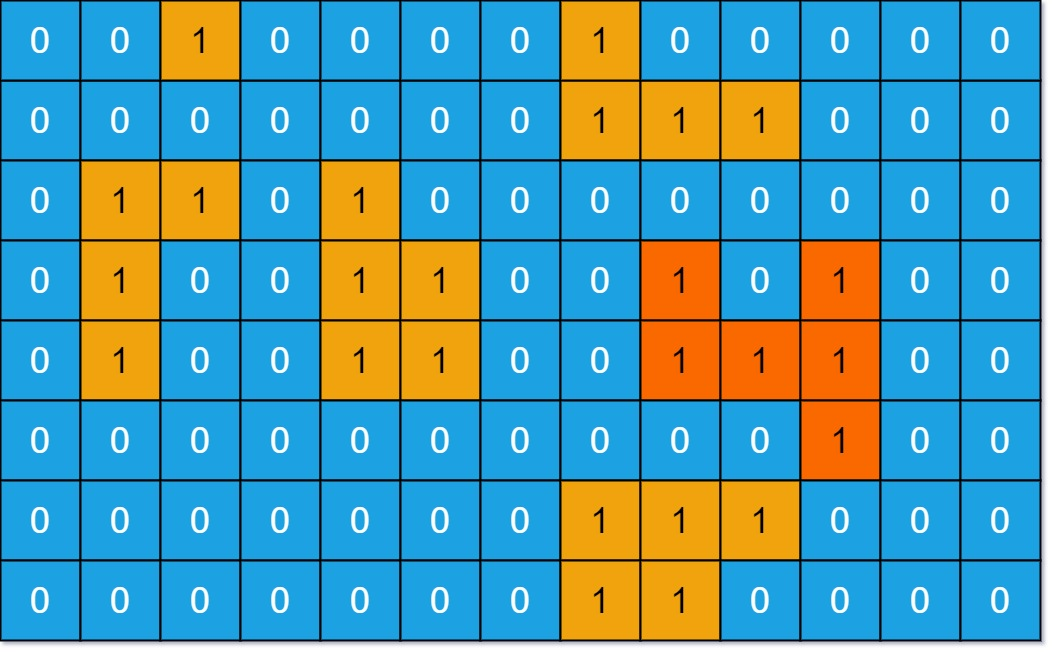

Input: grid = [[0,0,1,0,0,0,0,1,0,0,0,0,0],[0,0,0,0,0,0,0,1,1,1,0,0,0],[0,1,1,0,1,0,0,0,0,0,0,0,0],[0,1,0,0,1,1,0,0,1,0,1,0,0],[0,1,0,0,1,1,0,0,1,1,1,0,0],[0,0,0,0,0,0,0,0,0,0,1,0,0],[0,0,0,0,0,0,0,1,1,1,0,0,0],[0,0,0,0,0,0,0,1,1,0,0,0,0]]
Output: 6
Explanation: The answer is not 11, because the island must be connected 4-directionally.
Example 2:

Input: grid = [[0,0,0,0,0,0,0,0]]
Output: 0

In [ ]:
from typing import List
from collections import deque

class Solution:
    def maxAreaOfIsland(self, grid: List[List[int]]) -> int:
        if not grid: return 0
        
        max_area = 0
        total_rows, total_columns = len(grid), len(grid[0])
        visited = set()

        def bfs(i, j):
            queue = deque([(i, j)])
            visited.add((i, j)) # CORREÇÃO 1: Tupla (i, j)
            current_area = 0
            
            while queue:
                current_i, current_j = queue.popleft()
                current_area += 1
                
                directions = [(0, 1), (1, 0), (-1, 0), (0, -1)]
                for di, dj in directions:
                    ni, nj = current_i + di, current_j + dj
                    
                    # CORREÇÃO 2: Verificar ni, nj (o vizinho) e não i, j
                    if (0 <= ni < total_rows and 
                        0 <= nj < total_columns and 
                        grid[ni][nj] == 1 and 
                        (ni, nj) not in visited):
                        
                        queue.append((ni, nj))
                        visited.add((ni, nj))
            
            return current_area

        for row in range(total_rows):
            for column in range(total_columns):
                if grid[row][column] == 1 and (row, column) not in visited:
                    area = bfs(row, column)
                    max_area = max(max_area, area)
        
        return max_area